# Part 1 - Fundamtenal in simulating TDEM data

For a step-off waveform, simulate TDEM data for a conductive and non-permeable layered Earth.


In [2]:
# SimPEG functionality
import simpeg.electromagnetics.time_domain as tdem
from simpeg import maps
from simpeg.utils import plot_1d_layer_model

# Common Python functionality
import os
import numpy as np
from scipy.constants import mu_0
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({"font.size": 14})
write_output = False

Define a survey with source and receivers

In [3]:
# source properties 
source_location = np.array([0.0, 0.0, 1.0])
source_orientation = "z"
source_current = 1.0 
source_radius = 10.0

# receiver properties 
receiver_locations = np.array([0.0, 0.0, 1.0])
receiver_orientation = "z"
times = np.logspace(-5, -2, 31)

# waveform
stepoff_waveform = tdem.sources.StepOffWaveform(off_time=0.0)

# single receiver for each source, we have one source, one receiver
receiver_list = []
receiver_list.append(
    tdem.receivers.PointMagneticFluxDensity(
        receiver_locations, times, orientation=receiver_orientation
    )
)

# source list, and we have one source
source_list = []
source_list.append(
    tdem.sources.CircularLoop(
        receiver_list=receiver_list, 
        location=source_location, 
        orientation=source_orientation, 
        waveform=stepoff_waveform, 
        current=source_current, 
        radius=source_radius,
    )
)

survey = tdem.Survey(source_list)

Define a 1D layered Earth and the Model

In [11]:
# Layer conductivities, thickness, and number of layers
layer_conductivities = np.r_[0.1, 1.0, 0.1]
layer_thicknesses = np.r_[40.0, 40.0]
n_layers = len(layer_conductivities)

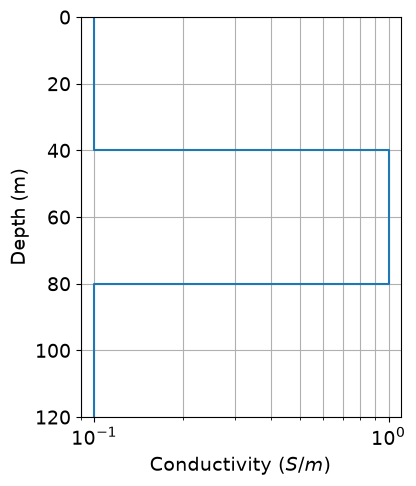

In [12]:
fig = plt.figure(figsize=(4,5))
ax1 = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax1 = plot_1d_layer_model(layer_thicknesses, layer_conductivities, scale="log", ax=ax1)
ax1.grid(which="both")
ax1.set_xlabel(r"Conductivity ($S/m$)")
plt.show()

### Models and Mappings for 1D Simulations

In [13]:
# Define model and mapping for a conduactivity model 
conductivity_model = layer_conductivities.copy()
conductivity_map = maps.IdentityMap(nP=n_layers)

# Define model and mappings for the parametric model
# Ordering in model parameters definition and wire mapping definition matters
parametric_model = np.r_[layer_thicknesses, np.log(1/layer_conductivities)]
wire_map = maps.Wires(("thicknesses", n_layers-1), ("log_resistivity", n_layers))
thicknesses_map = wire_map.thicknesses
log_resistivity_map = maps.ExpMap() * wire_map.log_resistivity

#### Define the Forward Simulation

In [15]:
simulation_conductivity = tdem.simulation_1d.Simulation1DLayered(
    survey=survey,
    sigmaMap=conductivity_map, 
    thicknesses=layer_thicknesses,
)

simulation_parametric = tdem.simulation_1d.Simulation1DLayered(
    survey=survey, 
    rhoMap=log_resistivity_map,
    thicknessesMap=thicknesses_map,
)

#### Predict 1D TDEM Data

In [16]:
dpred_conductivity = simulation_conductivity.dpred(conductivity_model)
dpred_parametric = simulation_parametric.dpred(parametric_model)

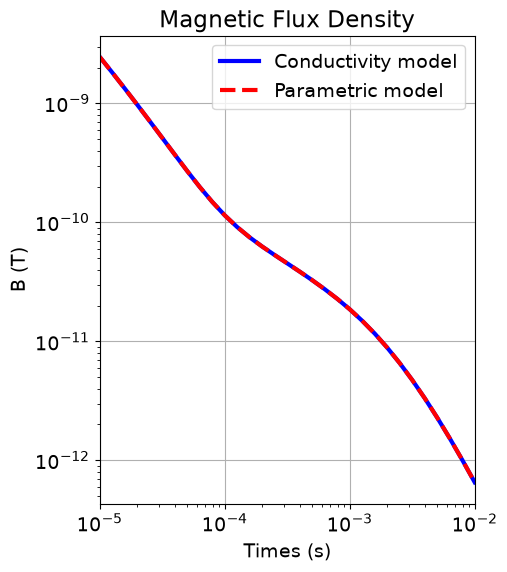

In [17]:
fig = plt.figure(figsize=(5, 6))
ax = fig.add_axes([0.2, 0.15, 0.75, 0.78])
ax.loglog(times, dpred_conductivity, "b-", lw=3)
ax.loglog(times, dpred_parametric, "r--", lw=3)
ax.set_xlim([times.min(), times.max()])
ax.grid()
ax.set_xlabel("Times (s)")
ax.set_ylabel("B (T)")
ax.set_title("Magnetic Flux Density")
ax.legend(["Conductivity model", "Parametric model"])
plt.show()

# Part 2 - TDEM simulation with Magnetic Permeability and Dispersive Physical Properties

### Case 1: the conductive layer is also magnetically permeable 

In [20]:
layer_susceptibilities = np.r_[0.0, 9.0, 0.0]
layer_premeabilities = mu_0 * (1 + layer_susceptibilities)

simulation_permeable = tdem.simulation_1d.Simulation1DLayered(
    survey=survey,
    sigmaMap=conductivity_map, 
    thicknesses=layer_thicknesses,
    mu=layer_premeabilities,
)

dpred_permeable = simulation_permeable.dpred(conductivity_model)

### Case 2: the middle layer is also chargeable (induced polarization)

In [21]:
eta = 0.5 # intrinsic chargeability [0, 1]
tau = 0.001 # central time-relaxation constant in seconds
c = 0.8 # phase constant [0, 1]

layer_eta = np.r_[1e-10, eta, 1e-10]
layer_tau = np.r_[0.0, tau, 0.0]
layer_c = np.r_[0.0, c, 0.0]

simulation_ip = tdem.simulation_1d.Simulation1DLayered(
    survey=survey,
    sigmaMap=conductivity_map, 
    thicknesses=layer_thicknesses,
    eta=layer_eta, 
    tau=layer_tau, 
    c=layer_c,
)

dpred_ip = simulation_ip.dpred(conductivity_model)

### Case 3: the top layer exhibits superparamagnetism (SPM)

In [28]:
chi = 0.01  # infinite susceptibility in SI
dchi = 0.01  # amplitude of frequency-dependent susceptibility contribution
tau1 = 1e-7  # lower limit for time relaxation constants in seconds
tau2 = 1.0  # upper limit for time relaxation constants in seconds

layer_mu = mu_0 * (1 + chi * np.r_[1.0, 0.0, 0.0])  # convert to permeability
layer_dchi = chi * np.r_[1.0, 0.0, 0.0]
layer_tau1 = tau1 * np.r_[1.0, 0.0, 0.0]
layer_tau2 = tau2 * np.r_[1.0, 0.0, 0.0]

simulation_spm = tdem.Simulation1DLayered(
    survey=survey,
    thicknesses=layer_thicknesses,
    sigmaMap=conductivity_map,
    mu=mu_0,
    dchi=dchi,
    tau1=tau1,
    tau2=tau2,
)

dpred_spm = simulation_spm.dpred(conductivity_model)

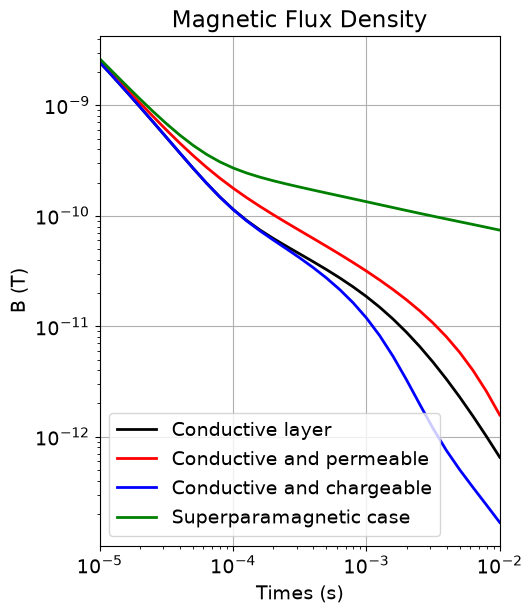

In [29]:
fig = plt.figure(figsize=(5, 6))
ax1 = fig.add_axes([0.1, 0.1, 0.8, 0.85])
ax1.loglog(times, np.abs(dpred_conductivity[0 : len(times)]), "k", lw=2)
ax1.loglog(times, np.abs(dpred_permeable[0 : len(times)]), "r", lw=2)
ax1.loglog(times, np.abs(dpred_ip[0 : len(times)]), "b", lw=2)
ax1.loglog(times, np.abs(dpred_spm[0 : len(times)]), "g", lw=2)
ax1.set_xlim([times.min(), times.max()])
ax1.grid()
ax1.legend(
    [
        "Conductive layer",
        "Conductive and permeable",
        "Conductive and chargeable",
        "Superparamagnetic case",
    ]
)
ax1.set_xlabel("Times (s)")
ax1.set_ylabel("B (T)")
ax1.set_title("Magnetic Flux Density")
plt.show()

# Part 3 - TDEM simulation with user-specified transmitter

### Defining Different Waveforms

In [30]:
# Rectangular waveform. The user may customize the waveform by setting the start
# time, end time and on time amplitude for the current waveform.
eps = 1e-6
ramp_on = np.r_[-0.004, -0.004 + eps]
ramp_off = np.r_[-eps, 0.0]
rectangular_waveform = tdem.sources.TrapezoidWaveform(
    ramp_on=ramp_on, ramp_off=ramp_off
)

# Triangular waveform. The user may customize the waveform by setting the start
# time, peak time, end time and peak amplitude for the current waveform.
eps = 1e-8
start_time = -0.02
peak_time = -0.01
off_time = 0.0
triangle_waveform = tdem.sources.TriangularWaveform(
    start_time=start_time, peak_time=peak_time, off_time=off_time
)

# General waveform. This is a fully general way to define the waveform.
# The use simply provides times and the current.


def custom_waveform(t, tmax):
    out = np.cos(0.5 * np.pi * (t - tmax) / (tmax + 0.02))
    out[t >= tmax] = 1 + (t[t >= tmax] - tmax) / tmax
    return out


waveform_times = np.r_[np.linspace(-0.02, -0.011, 10), -np.logspace(-2, -6, 61), 0.0]
waveform_current = custom_waveform(waveform_times, -0.0055)
general_waveform = tdem.sources.PiecewiseLinearWaveform(
    times=waveform_times, currents=waveform_current
)

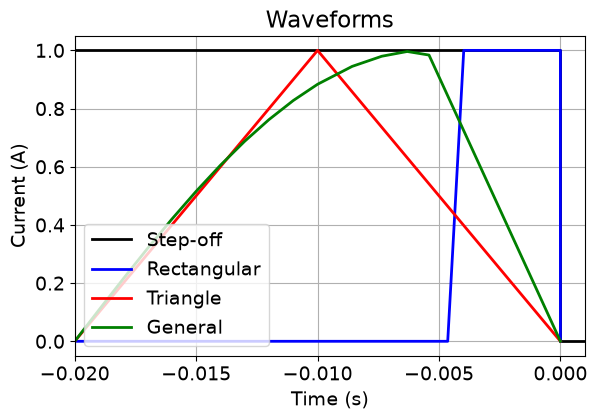

In [31]:
fig = plt.figure(figsize=(6, 4))
ax = fig.add_axes([0.1, 0.1, 0.85, 0.8])

ax.plot(np.r_[-2e-2, 0.0, 1e-10, 1e-3], np.r_[1.0, 1.0, 0.0, 0.0], "k", lw=2)
plotting_current = [rectangular_waveform.eval(t) for t in waveform_times]
ax.plot(waveform_times, plotting_current, "b", lw=2)
plotting_current = [triangle_waveform.eval(t) for t in waveform_times]
ax.plot(waveform_times, plotting_current, "r", lw=2)
plotting_current = [general_waveform.eval(t) for t in waveform_times]
ax.plot(waveform_times, plotting_current, "g", lw=2)

ax.grid()
ax.set_xlim([waveform_times.min(), 1e-3])
ax.set_xlabel("Time (s)")
ax.set_ylabel("Current (A)")
ax.set_title("Waveforms")
ax.legend(["Step-off", "Rectangular", "Triangle", "General"], loc="lower left")
plt.show()

### Designing a Survey with Multiple Sources

In [32]:
waveforms_list = [
    stepoff_waveform,
    rectangular_waveform,
    triangle_waveform,
    general_waveform,
]

receiver_list_multi = [
    tdem.receivers.PointMagneticFluxDensity(
        receiver_locations, times, orientation=receiver_orientation
    )
]

source_list_multi = []

for w in waveforms_list:
    source_list_multi.append(
        tdem.sources.CircularLoop(
            receiver_list=receiver_list_multi,
            location=source_location,
            waveform=w,
            current=source_current,
            radius=source_radius,
        )
    )

# Define the survey
survey_multi = tdem.Survey(source_list_multi)

In [33]:
simulation_waveforms = tdem.Simulation1DLayered(
    survey=survey_multi, 
    thicknesses=layer_thicknesses, 
    sigmaMap=conductivity_map
)

dpred_waveforms = simulation_waveforms.dpred(conductivity_model)

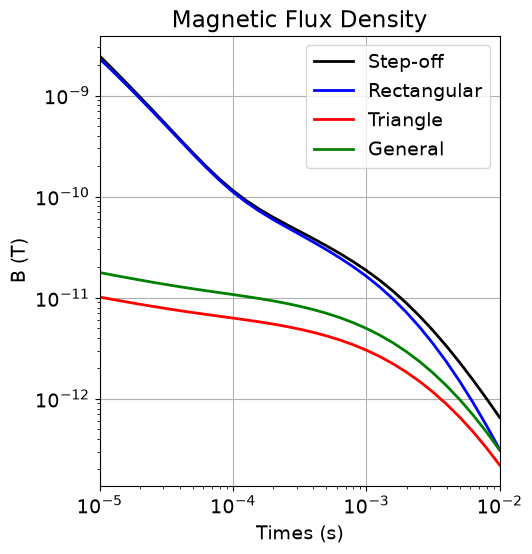

In [34]:
fig = plt.figure(figsize=(5, 6))
d = np.reshape(dpred_waveforms, (len(source_list_multi), len(times))).T
ax = fig.add_axes([0.15, 0.15, 0.8, 0.75])
colorlist = ["k", "b", "r", "g"]
for ii, k in enumerate(colorlist):
    ax.loglog(times, np.abs(d[:, ii]), k, lw=2)

ax.set_xlim([times.min(), times.max()])
ax.grid()
ax.legend(["Step-off", "Rectangular", "Triangle", "General"])
ax.set_xlabel("Times (s)")
ax.set_ylabel("B (T)")
ax.set_title("Magnetic Flux Density")
plt.show()